In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
batch_size = 128
epochs = 50
lr = 0.0002
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mnist_gan")
global_step = 0


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        return img.view(img.size(0), 1, 28, 28)

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [5]:
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

g_losses, d_losses = [], []

for epoch in range(epochs):
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # Train Discriminator
        D.zero_grad()
        real_out = D(real_imgs)
        d_real_loss = criterion(real_out, real_labels)

        z = torch.randn(bs, latent_dim, device=device)
        fake_imgs = G(z)
        fake_out = D(fake_imgs.detach())
        d_fake_loss = criterion(fake_out, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        opt_D.step()

        # Train Generator
        G.zero_grad()
        fake_out = D(fake_imgs)
        g_loss = criterion(fake_out, real_labels)
        g_loss.backward()
        opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    writer.add_scalar("Loss/Generator", g_loss.item(), epoch)
    writer.add_scalar("Loss/Discriminator", d_loss.item(), epoch)
    # Log generated image grid every 5 epochs
    if (epoch + 1) % 5 == 0:
        G.eval()
        with torch.no_grad():
            z_sample = torch.randn(16, latent_dim, device=device)
            sample_imgs = G(z_sample)
            from torchvision.utils import make_grid
            grid = make_grid(sample_imgs, nrow=4, normalize=True, value_range=(-1,1))
            writer.add_image("Generated/samples", grid, epoch)
        G.train()

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

Epoch [1/50]  D Loss: 0.5850  G Loss: 5.4258
Epoch [2/50]  D Loss: 0.1992  G Loss: 3.4288
Epoch [3/50]  D Loss: 0.0821  G Loss: 4.4795
Epoch [4/50]  D Loss: 0.5957  G Loss: 10.3618
Epoch [5/50]  D Loss: 0.1492  G Loss: 4.0306
Epoch [6/50]  D Loss: 0.3785  G Loss: 4.8530
Epoch [7/50]  D Loss: 0.2262  G Loss: 4.1929
Epoch [8/50]  D Loss: 0.2056  G Loss: 2.3183
Epoch [9/50]  D Loss: 0.1693  G Loss: 3.5549
Epoch [10/50]  D Loss: 0.4914  G Loss: 2.3483
Epoch [11/50]  D Loss: 0.3861  G Loss: 3.2838
Epoch [12/50]  D Loss: 0.6221  G Loss: 1.7088
Epoch [13/50]  D Loss: 0.7577  G Loss: 1.5259
Epoch [14/50]  D Loss: 0.8135  G Loss: 2.3470
Epoch [15/50]  D Loss: 1.1575  G Loss: 1.0639
Epoch [16/50]  D Loss: 0.8323  G Loss: 1.6355
Epoch [17/50]  D Loss: 1.1404  G Loss: 1.0834
Epoch [18/50]  D Loss: 1.1261  G Loss: 1.0846
Epoch [19/50]  D Loss: 0.9903  G Loss: 1.2203
Epoch [20/50]  D Loss: 1.0879  G Loss: 1.4705
Epoch [21/50]  D Loss: 1.1252  G Loss: 1.0435
Epoch [22/50]  D Loss: 0.9635  G Loss: 1.3

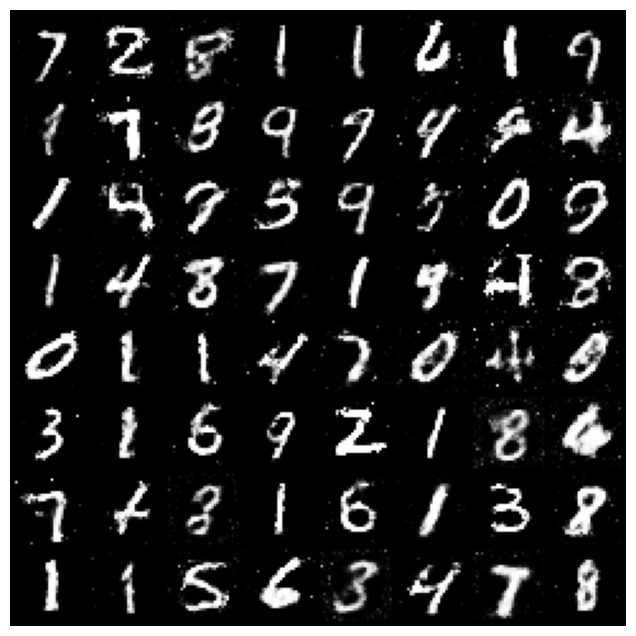

In [6]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, device=device)
    samples = G(z).cpu()

grid = make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(8,8))
plt.axis("off")
plt.imshow(grid.permute(1,2,0))
plt.show()

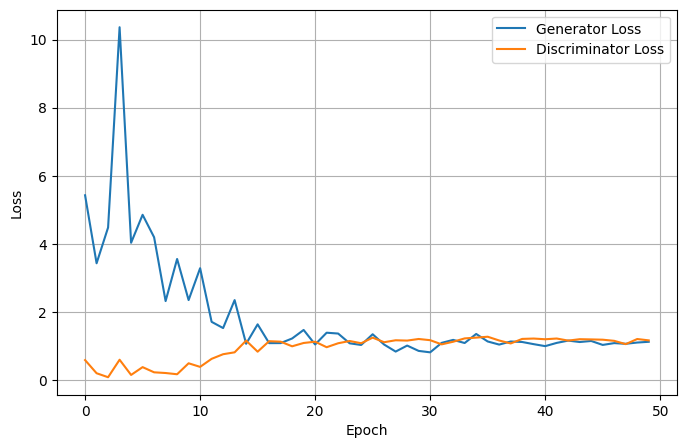

In [7]:
writer.close()

plt.figure(figsize=(8,5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()